<a href="https://colab.research.google.com/github/TribuneAlpha/2026_Spring_classes/blob/main/CSC576FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Importing and Processing Data

In [154]:
import pandas as pd
import numpy as np

# Column names based on NASA dataset structure
columns = ['unit', 'cycle'] + \
          [f'op_setting_{i}' for i in range(1, 4)] + \
          [f'sensor_{i}' for i in range(1, 22)]

# Load dataset (adjust path if needed)
df = pd.read_csv('/content/train_FD001.txt',
                 sep=' ',
                 header=None)

# Dropping unnessicary columns (26 & 27 are pure NA)
df = df.dropna(axis=1)

# Assign column names
df.columns = columns

# Preview
df.head()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [155]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData types:\n", df.dtypes)

Shape: (20631, 26)

Columns:
 Index(['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21'],
      dtype='object')

Data types:
 unit              int64
cycle             int64
op_setting_1    float64
op_setting_2    float64
op_setting_3    float64
sensor_1        float64
sensor_2        float64
sensor_3        float64
sensor_4        float64
sensor_5        float64
sensor_6        float64
sensor_7        float64
sensor_8        float64
sensor_9        float64
sensor_10       float64
sensor_11       float64
sensor_12       float64
sensor_13       float64
sensor_14       float64
sensor_15       float64
sensor_16       float64
sensor_17         int64
sensor_18         int64
sensor_19       f

In [156]:
print(df.columns)

Index(['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21'],
      dtype='object')


In [157]:
print("Number of engines:", df['unit'].nunique())

# Max cycle per engine (important for RUL)
engine_life = df.groupby('unit')['cycle'].max()

print("\nEngine life stats:")
print(engine_life.describe())

Number of engines: 100

Engine life stats:
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


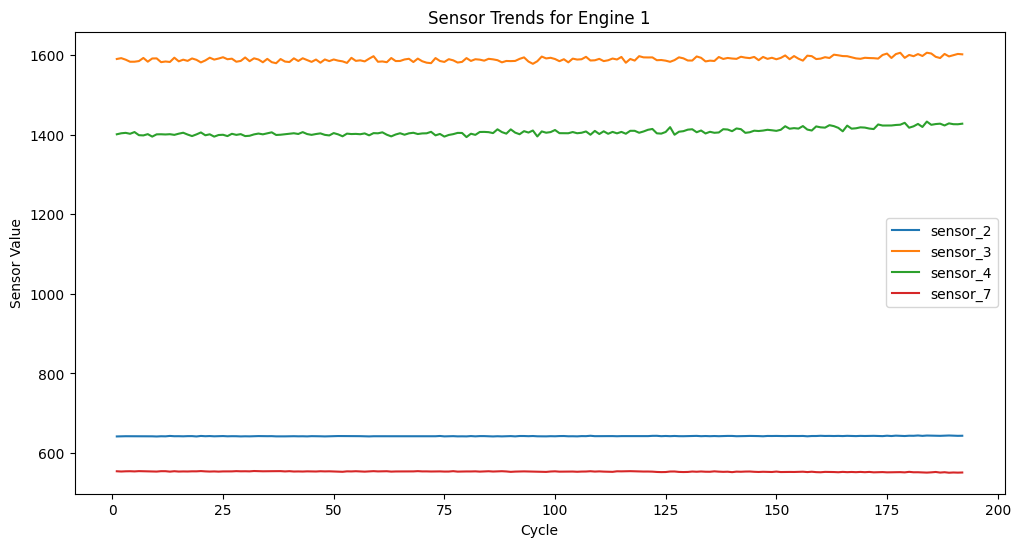

In [158]:
import matplotlib.pyplot as plt

# Pick one engine to visualize
engine_id = 1
engine_df = df[df['unit'] == engine_id]

# Plot a few sensors
sensors_to_plot = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7']

plt.figure(figsize=(12, 6))

for sensor in sensors_to_plot:
    plt.plot(engine_df['cycle'], engine_df[sensor], label=sensor)

plt.xlabel('Cycle')
plt.ylabel('Sensor Value')
plt.title(f'Sensor Trends for Engine {engine_id}')
plt.legend()
plt.show()

In [159]:
# Check variance of each sensor
sensor_cols = [col for col in df.columns if 'sensor' in col]

variance = df[sensor_cols].var()

# Sort and display
print(variance.sort_values())

sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    2.422479e-28
sensor_10    2.172333e-25
sensor_5     1.152399e-23
sensor_1     4.273435e-21
sensor_6     1.929279e-06
sensor_15    1.406628e-03
sensor_8     5.038938e-03
sensor_13    5.172330e-03
sensor_21    1.171825e-02
sensor_20    3.266927e-02
sensor_11    7.133568e-02
sensor_2     2.500533e-01
sensor_12    5.439850e-01
sensor_7     7.833883e-01
sensor_17    2.398667e+00
sensor_3     3.759099e+01
sensor_4     8.101089e+01
sensor_14    3.639005e+02
sensor_9     4.876536e+02
dtype: float64


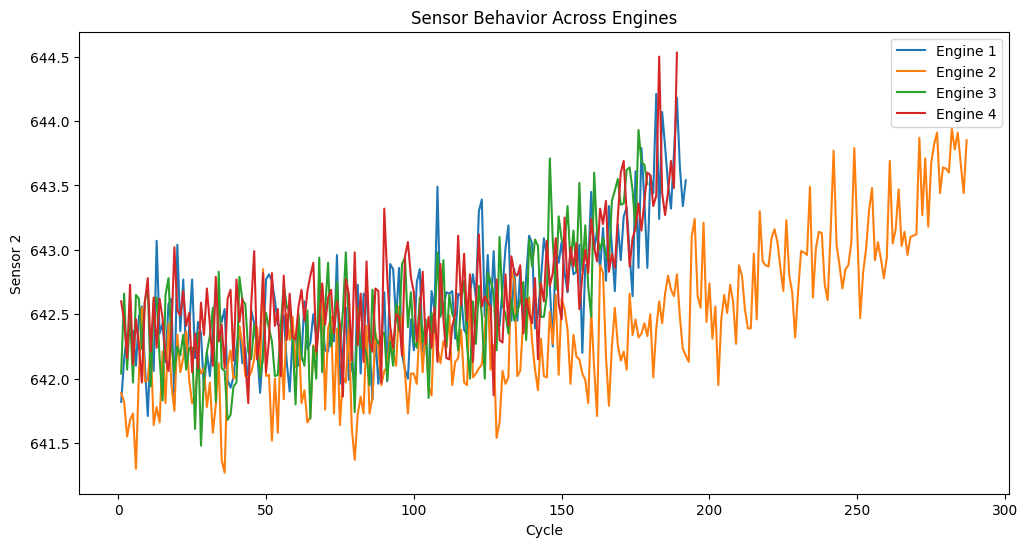

In [160]:
plt.figure(figsize=(12, 6))

for engine_id in [1, 2, 3, 4]:
    temp_df = df[df['unit'] == engine_id]
    plt.plot(temp_df['cycle'], temp_df['sensor_2'], label=f'Engine {engine_id}')

plt.xlabel('Cycle')
plt.ylabel('Sensor 2')
plt.title('Sensor Behavior Across Engines')
plt.legend()
plt.show()

In [161]:
from sklearn.preprocessing import StandardScaler

# Select feature columns (exclude unit, cycle, RUL)
feature_cols = [col for col in df.columns if col not in ['unit', 'cycle', 'RUL']]

scaler = StandardScaler()

df[feature_cols] = scaler.fit_transform(df[feature_cols])

df.head()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.315980,-1.372953,0.0,0.0,-1.721725,-0.134255,-0.925936,-1.776357e-15,0.141683,1.121141,-0.516338,-0.862813,0.0,-0.266467,0.334262,-1.058890,-0.269071,-0.603816,-1.387779e-17,-0.781710,0.0,0.0,1.348493,1.194427
1,1,2,0.872722,-1.031720,0.0,0.0,-1.061780,0.211528,-0.643726,-1.776357e-15,0.141683,0.431930,-0.798093,-0.958818,0.0,-0.191583,1.174899,-0.363646,-0.642845,-0.275852,-1.387779e-17,-0.781710,0.0,0.0,1.016528,1.236922
2,1,3,-1.961874,1.015677,0.0,0.0,-0.661813,-0.413166,-0.525953,-1.776357e-15,0.141683,1.008155,-0.234584,-0.557139,0.0,-1.015303,1.364721,-0.919841,-0.551629,-0.649144,-1.387779e-17,-2.073094,0.0,0.0,0.739891,0.503423
3,1,4,0.324090,-0.008022,0.0,0.0,-0.661813,-1.261314,-0.784831,-1.776357e-15,0.141683,1.222827,0.188048,-0.713826,0.0,-1.539489,1.961302,-0.224597,-0.520176,-1.971665,-1.387779e-17,-0.781710,0.0,0.0,0.352598,0.777792
4,1,5,-0.864611,-0.690488,0.0,0.0,-0.621816,-1.251528,-0.301518,-1.776357e-15,0.141683,0.714393,-0.516338,-0.457059,0.0,-0.977861,1.052871,-0.780793,-0.521748,-0.339845,-1.387779e-17,-0.136018,0.0,0.0,0.463253,1.059552


In [162]:
import numpy as np

def create_sequences_with_ids(data, seq_length, feature_cols, target_col):
    X = []
    y = []
    engine_ids = []

    for unit in data['unit'].unique():
        unit_df = data[data['unit'] == unit]

        for i in range(len(unit_df) - seq_length):
            seq_x = unit_df[feature_cols].iloc[i:i+seq_length].values
            seq_y = unit_df[target_col].iloc[i+seq_length]

            X.append(seq_x)
            y.append(seq_y)
            engine_ids.append(unit)  # 👈 THIS FIXES EVERYTHING

    return np.array(X), np.array(y), np.array(engine_ids)

In [163]:
SEQ_LENGTH = 30  # common choice (you can tune later)

# Calculate RUL (Remaining Useful Life)
# For each engine ('unit'), find the maximum 'cycle' it reached.
# Then, for each row, RUL = (max_cycle_for_that_unit) - (current_cycle)
max_cycles_per_unit = df.groupby('unit')['cycle'].max().reset_index()
max_cycles_per_unit.rename(columns={'cycle': 'max_cycle'}, inplace=True)
df = df.merge(max_cycles_per_unit, on='unit', how='left')
df['RUL'] = df['max_cycle'] - df['cycle']
df.drop(columns=['max_cycle'], inplace=True)

X, y, engine_IDS = create_sequences_with_ids(df, SEQ_LENGTH, feature_cols, 'RUL')

print("X shape:", X.shape)  # (samples, time_steps, features)
print("y shape:", y.shape)

X shape: (17631, 30, 24)
y shape: (17631,)


In [164]:
from sklearn.model_selection import train_test_split

# Get unique engine IDs
units = df['unit'].unique()

train_units, test_units = train_test_split(units, test_size=0.2, random_state=42)

train_df = df[df['unit'].isin(train_units)]
test_df = df[df['unit'].isin(test_units)]

# Create sequences separately
X_train, y_train, train_engine_ids = create_sequences_with_ids(
    train_df, SEQ_LENGTH, feature_cols, 'RUL'
)

X_test, y_test, test_engine_ids = create_sequences_with_ids(
    test_df, SEQ_LENGTH, feature_cols, 'RUL'
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (14161, 30, 24)
Test shape: (3470, 30, 24)


# Data pre-processing Done
Data has been split and formmated

# Time for features:



In [166]:
import pandas as pd
import numpy as np

window_sizes = [5, 10, 20]

# Fix: Ensure sensor_cols only includes the original sensor measurements.
# The `columns` variable from the initial data loading cell (Jv7RKnigdcEN) holds these original names.
# We filter `columns` to get only the original sensor columns (sensor_1 to sensor_21).
original_sensor_cols = [col for col in columns if "sensor" in col]

feature_frames = []

for sensor in original_sensor_cols:
    for w in window_sizes:

        roll_mean = df.groupby('unit')[sensor].transform(lambda x: x.rolling(w).mean())
        roll_std = df.groupby('unit')[sensor].transform(lambda x: x.rolling(w).std())

        feature_frames.append(pd.DataFrame({
            f'{sensor}_mean_{w}': roll_mean,
            f'{sensor}_std_{w}': roll_std
        }))

# Combine once (avoids fragmentation)
df_features = pd.concat(feature_frames, axis=1)

# Merge back ONCE
# To prevent column duplication if the cell is run multiple times,
# first drop any previously created feature columns from df.
existing_feature_cols = [col for col in df.columns if any(f'_mean_{w}' in col or f'_std_{w}' in col for w in window_sizes)]
df = df.drop(columns=existing_feature_cols, errors='ignore')

df = pd.concat([df, df_features], axis=1)

df = df.bfill()

In [167]:
import numpy as np
import pandas as pd

window = 10
# Use the original sensor columns for slope calculation.
# This prevents trying to calculate slopes on already-derived features (mean/std)
# which might lead to unexpected type issues or logical inconsistencies.
sensor_cols_for_slope = [col for col in columns if "sensor" in col]

# Precompute time index once (faster slope approximation)
t = np.arange(window)
t = t - t.mean()
denom = np.sum(t**2)

slope_features = []

for sensor in sensor_cols_for_slope:

    # rolling window matrix (fast vectorized view)
    rolled = (
        df.groupby("unit")[sensor]
        .rolling(window)
        .apply(lambda x: np.dot(x - x.mean(), t) / denom, raw=True)
        .reset_index(level=0, drop=True)
    )

    slope_features.append(rolled.rename(f"{sensor}_slope_{window}"))

# Combine all slope features at once (avoids fragmentation)
df_slope = pd.concat(slope_features, axis=1)

# To prevent column duplication if the cell is run multiple times,
# first drop any previously created slope feature columns from df.
existing_slope_cols = [col for col in df.columns if '_slope_' in col]
df = df.drop(columns=existing_slope_cols, errors='ignore')

df = pd.concat([df, df_slope], axis=1)

df = df.bfill()

In [168]:
# Normalize sensors first (important for combining them)
from sklearn.preprocessing import MinMaxScaler

health_cols = sensor_cols

scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[health_cols] = scaler.fit_transform(df_scaled[health_cols])

# Health index = average sensor condition
df['health_index'] = df_scaled[health_cols].mean(axis=1)

In [169]:
import pandas as pd

sensor_cols = [col for col in df.columns if "sensor" in col]

diff_features = []

for sensor in sensor_cols:
    diff = df.groupby('unit')[sensor].diff()

    diff_features.append(pd.DataFrame({
        f'{sensor}_diff': diff
    }))

# Combine all at once (fixes fragmentation)
df_diff = pd.concat(diff_features, axis=1)

# Merge back once
df = pd.concat([df, df_diff], axis=1)

# Clean missing values
df = df.bfill()

# Features extracted
# time to run models

In [170]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import time

In [171]:
from sklearn.linear_model import LinearRegression

start = time.time()

lr = LinearRegression()
lr.fit(X_train_flat, y_train)

pred_lr = lr.predict(X_test_flat)

end = time.time()

In [172]:
mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

print("Linear Regression Results")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("Training time (sec):", end - start)

Linear Regression Results
MAE: 23.098507165873126
RMSE: 29.12013065001786
Training time (sec): 2.983180284500122


In [173]:
from sklearn.ensemble import RandomForestRegressor
import time

start = time.time()

rf = RandomForestRegressor(
    n_estimators=50,        # reduced from 80 → major speed gain
    max_depth=12,           # prevents overly deep, slow trees (20 is expensive)
    min_samples_leaf=10,    # reduces unnecessary splits → faster + smoother trees
    max_features='sqrt',    # IMPORTANT: reduces feature search space per split
    n_jobs=-1,              # parallel processing (use all CPU cores)
    random_state=42
)

rf.fit(X_train_flat, y_train)

pred_rf = rf.predict(X_test_flat)

end = time.time()

In [174]:
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("Training time (sec):", end - start)

Random Forest Results
MAE: 21.39559938352806
RMSE: 29.25891418009594
Training time (sec): 5.951052665710449


In [175]:
from sklearn.ensemble import GradientBoostingRegressor
import time
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

start = time.time()

gb_opt = GradientBoostingRegressor(
    n_estimators=80,        # ↓ major speed boost
    learning_rate=0.08,     # ↑ compensate for fewer trees
    max_depth=3,            # keep trees shallow (critical)
    subsample=0.8,          # stochastic boosting (faster + better generalization)
    max_features="sqrt",    # HUGE speed improvement in high dimensions
    random_state=42
)

gb_opt.fit(X_train_flat, y_train)

pred = gb_opt.predict(X_test_flat)

end = time.time()

In [176]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_gb = mean_absolute_error(y_test, pred)
rmse_gb = np.sqrt(mean_squared_error(y_test, pred))

print("Gradient Boosting Results")
print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("Training time (sec):", end - start)

Gradient Boosting Results
MAE: 21.254802049586992
RMSE: 28.667546721533327
Training time (sec): 7.037050247192383


# Model Basic Runing/Metrics over
# In-depth analysis begins

In [177]:
# Rebuild test structure (IMPORTANT)
test_units = df[df['unit'].isin(test_units)]['unit'].values

In [178]:
def plot_engine_predictions(engine_id, preds, y_true, engine_ids):

    mask = engine_ids == engine_id

    true_vals = y_true[mask]
    pred_vals = preds[mask]

    if len(true_vals) == 0:
        print(f"No data for Engine {engine_id}")
        return

    plt.figure(figsize=(10,5))
    plt.plot(true_vals, label="Actual RUL")
    plt.plot(pred_vals, label="Predicted RUL")

    plt.title(f"Engine {engine_id} - RUL Prediction")
    plt.xlabel("Time Step")
    plt.ylabel("RUL")
    plt.legend()
    plt.show()

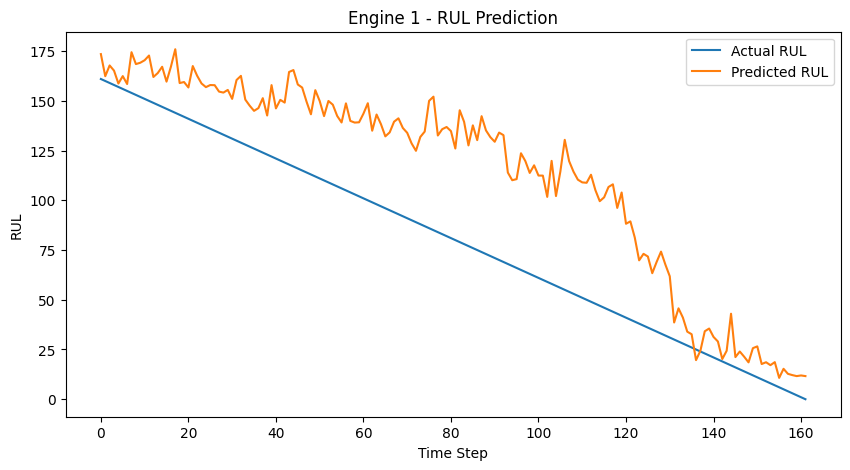

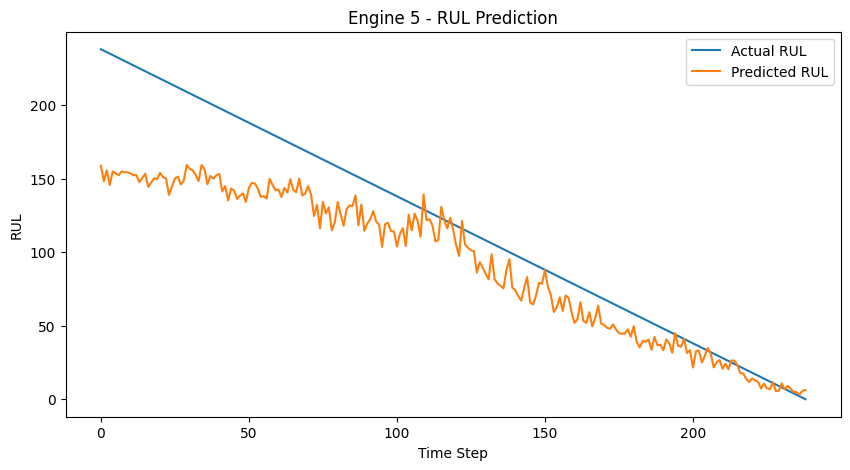

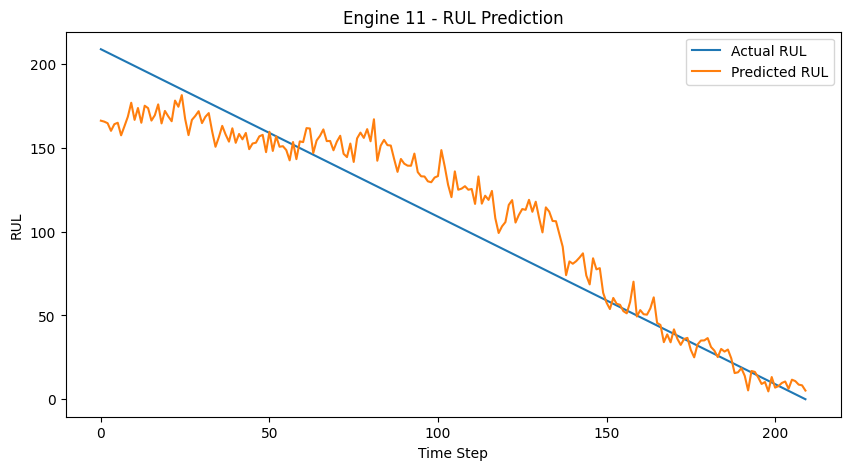

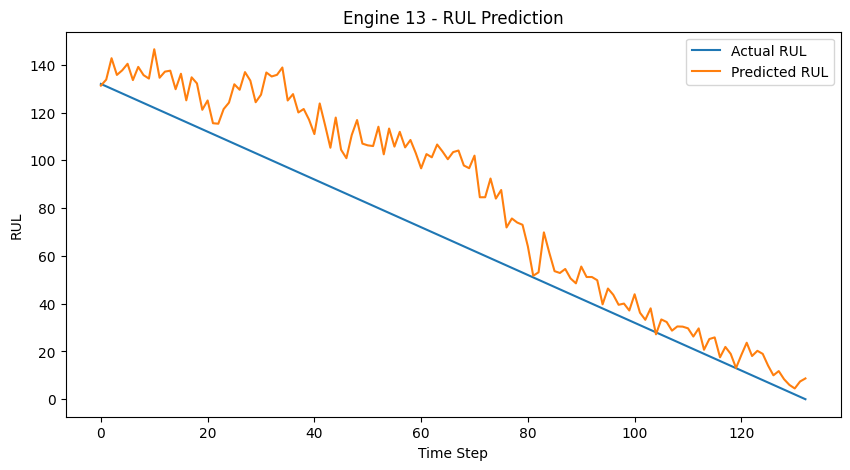

In [179]:
# choose your best model predictions
model_preds = pred  # gb predictions from earlier

# plot a few engines
for engine_id in np.unique(test_engine_ids)[:4]:
    plot_engine_predictions(engine_id, pred, y_test, test_engine_ids)

In [180]:
FAILURE_THRESHOLD = 30  # cycles
y_true_class = (y_test <= FAILURE_THRESHOLD).astype(int)
y_pred_class = (pred <= FAILURE_THRESHOLD).astype(int)

In [181]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_true_class, y_pred_class))

print("\nClassification Report:")
print(classification_report(y_true_class, y_pred_class))

[[2783   67]
 [  84  536]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      2850
           1       0.89      0.86      0.88       620

    accuracy                           0.96      3470
   macro avg       0.93      0.92      0.93      3470
weighted avg       0.96      0.96      0.96      3470



In [182]:
import matplotlib.pyplot as plt

def plot_with_threshold(engine_id, preds, y_true, engine_ids, threshold):

    mask = engine_ids == engine_id

    true_vals = y_true[mask]
    pred_vals = preds[mask]

    plt.figure(figsize=(10,5))

    plt.plot(true_vals, label="Actual RUL")
    plt.plot(pred_vals, label="Predicted RUL")

    # Threshold line
    plt.axhline(threshold, linestyle='--', label="Failure Threshold")

    plt.title(f"Engine {engine_id} - Early Warning")
    plt.xlabel("Time Step")
    plt.ylabel("RUL")
    plt.legend()
    plt.show()

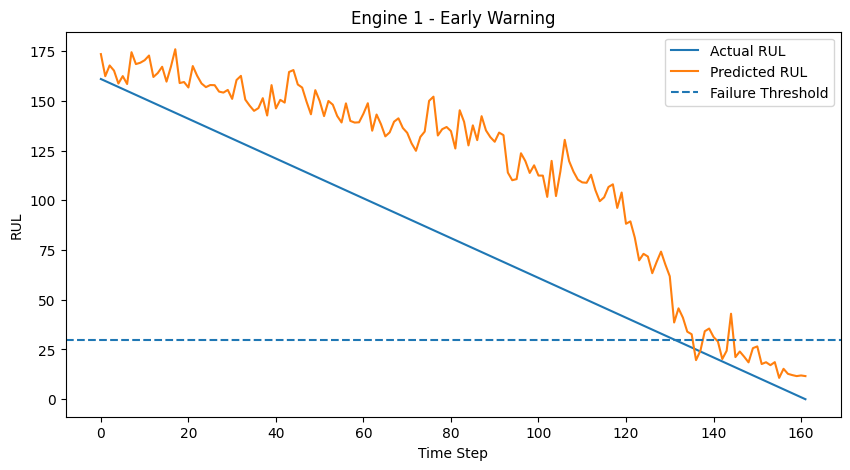

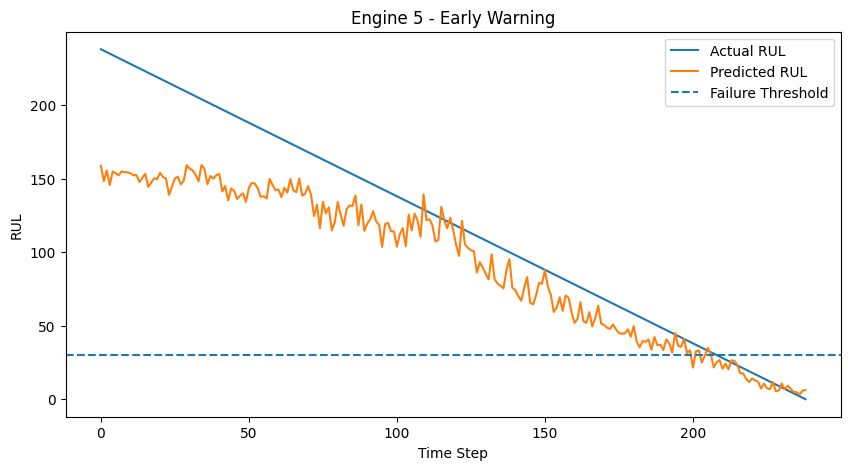

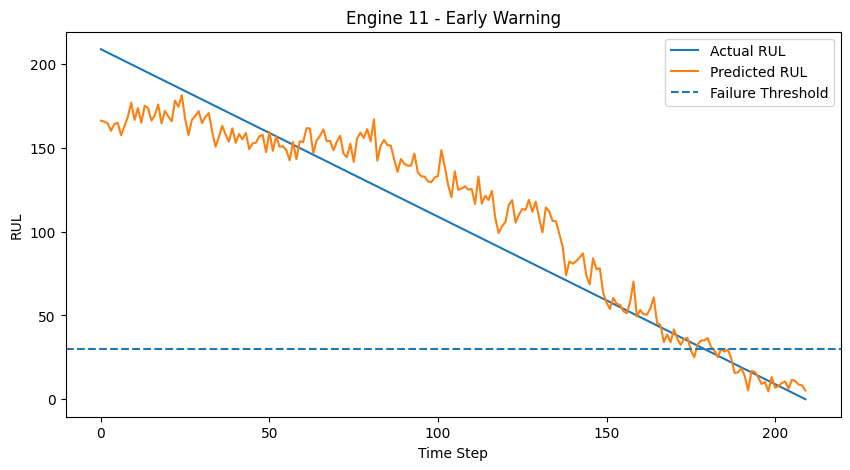

In [183]:
for engine_id in np.unique(test_engine_ids)[:3]:
    plot_with_threshold(engine_id, pred, y_test, test_engine_ids, FAILURE_THRESHOLD)

In [184]:
def compute_warning_time(y_true, y_pred, threshold):

    true_cross = np.where(y_true <= threshold)[0]
    pred_cross = np.where(y_pred <= threshold)[0]

    if len(true_cross) == 0 or len(pred_cross) == 0:
        return None

    return true_cross[0] - pred_cross[0]

In [185]:
warning_times = []

for engine_id in np.unique(test_engine_ids):

    mask = test_engine_ids == engine_id

    wt = compute_warning_time(
        y_test[mask],
        pred[mask],
        FAILURE_THRESHOLD
    )

    if wt is not None:
        warning_times.append(wt)

print("Average warning lead time:", np.mean(warning_times))

Average warning lead time: 2.15


# Model result processing over.

# I'm going to now generate a bunch of useful images:

In [186]:
import numpy as np
import pandas as pd

# Extract importance
importances = gb_opt.feature_importances_

# Check shape
print("Feature importance shape:", importances.shape)

Feature importance shape: (720,)


In [187]:
feature_names = []

for t in range(SEQ_LENGTH):
    for col in feature_cols:
        feature_names.append(f"{col}_t{t}")

In [188]:
feat_imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feat_imp_df = feat_imp_df.sort_values(by="importance", ascending=False)

feat_imp_df.head(10)

,feature,importance
662,sensor_12_t27,0.083527
614,sensor_12_t25,0.070547
541,sensor_11_t22,0.068285
486,sensor_4_t20,0.057042
590,sensor_12_t24,0.050233
558,sensor_4_t23,0.042692
709,sensor_11_t29,0.038052
705,sensor_7_t29,0.037287
685,sensor_11_t28,0.034398
657,sensor_7_t27,0.026206


In [189]:
feat_imp_df['sensor'] = feat_imp_df['feature'].apply(lambda x: x.split('_t')[0])

sensor_importance = feat_imp_df.groupby('sensor')['importance'].sum()
sensor_importance = sensor_importance.sort_values(ascending=False)

sensor_importance.head(10)

,importance
sensor,
sensor_12,0.257295
sensor_11,0.194163
sensor_4,0.165289
sensor_7,0.100505
sensor_9,0.097390
sensor_14,0.061917
sensor_15,0.033412
sensor_20,0.029668
sensor_21,0.022830


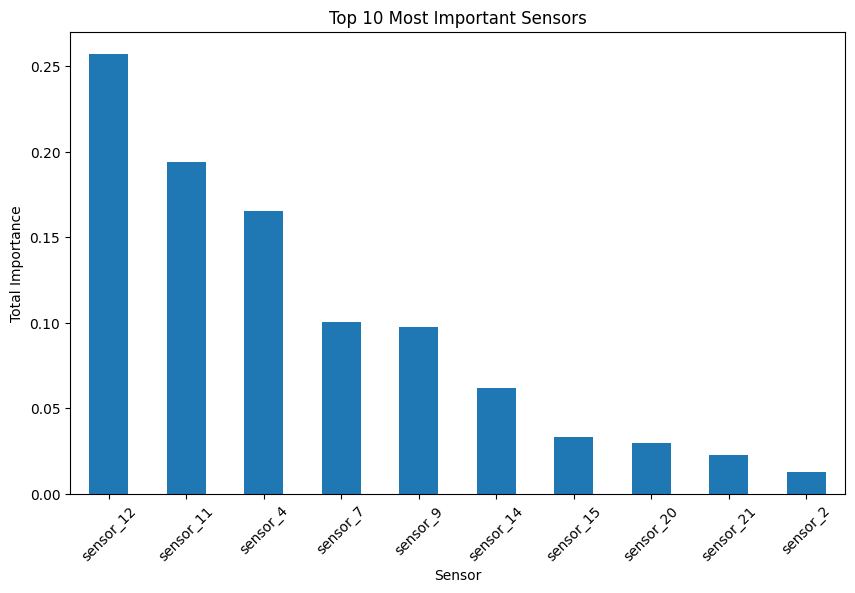

In [190]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sensor_importance.head(10).plot(kind='bar')

plt.title("Top 10 Most Important Sensors")
plt.ylabel("Total Importance")
plt.xlabel("Sensor")
plt.xticks(rotation=45)

plt.show()

Turned out to later discard this 'important sensor' path of logic, but interesting nonetheless

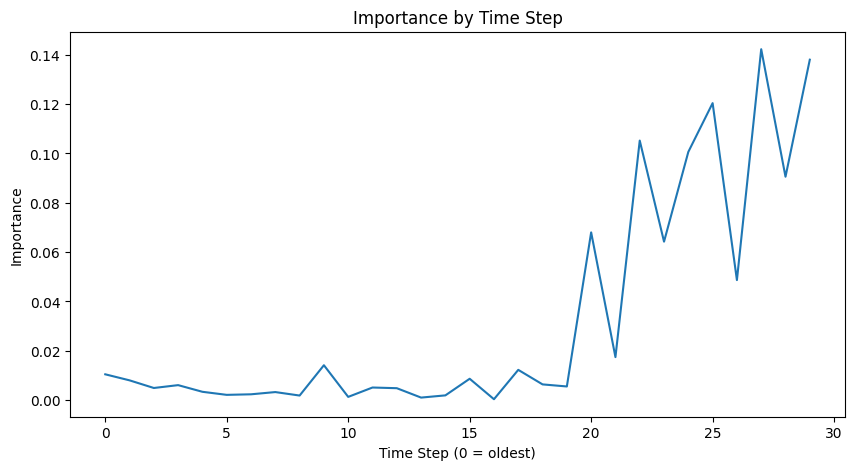

In [191]:
feat_imp_df['timestep'] = feat_imp_df['feature'].apply(lambda x: int(x.split('_t')[1]))

time_importance = feat_imp_df.groupby('timestep')['importance'].sum()

plt.figure(figsize=(10,5))
plt.plot(time_importance)

plt.title("Importance by Time Step")
plt.xlabel("Time Step (0 = oldest)")
plt.ylabel("Importance")

plt.show()

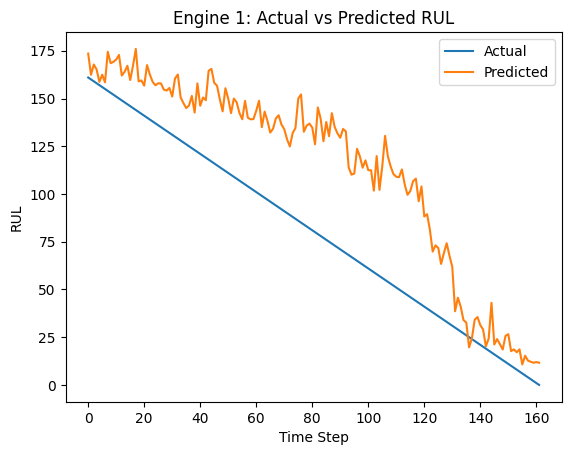

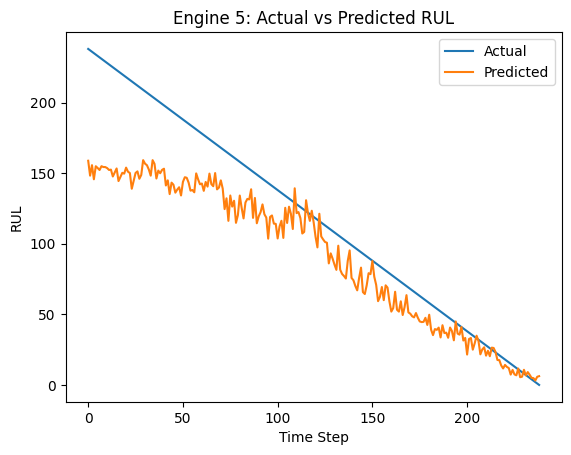

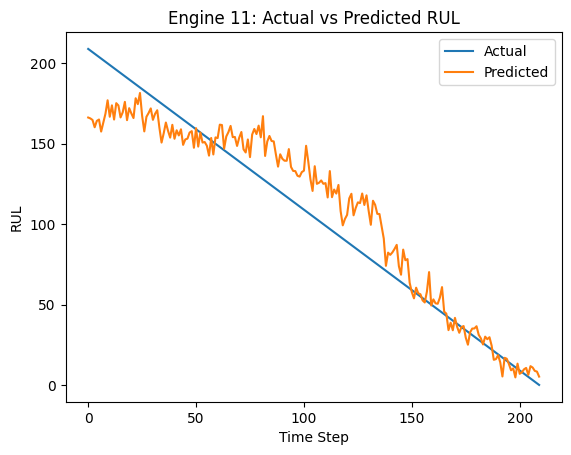

In [192]:
import matplotlib.pyplot as plt
import numpy as np

def plot_rul_predictions(engine_id, preds, y_true, engine_ids):
    mask = engine_ids == engine_id

    plt.figure()
    plt.plot(y_true[mask])
    plt.plot(preds[mask])

    plt.title(f"Engine {engine_id}: Actual vs Predicted RUL")
    plt.xlabel("Time Step")
    plt.ylabel("RUL")
    plt.legend(["Actual", "Predicted"])

    plt.savefig(f"rul_engine_{engine_id}.png", dpi=300, bbox_inches='tight')
    plt.show()

# Example usage
for eid in np.unique(test_engine_ids)[:3]:
    plot_rul_predictions(eid, pred, y_test, test_engine_ids)

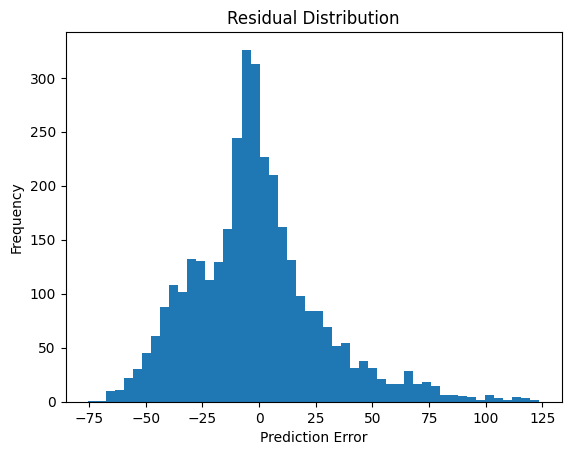

In [193]:
residuals = y_test - pred

plt.figure()
plt.hist(residuals, bins=50)

plt.title("Residual Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.savefig("residual_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

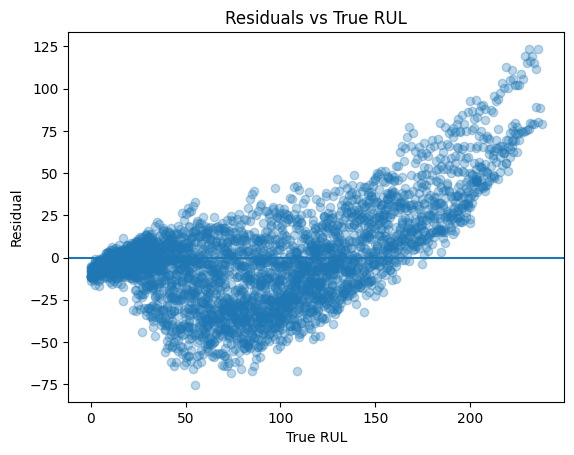

In [194]:
plt.figure()
plt.scatter(y_test, residuals, alpha=0.3)

plt.axhline(0)

plt.title("Residuals vs True RUL")
plt.xlabel("True RUL")
plt.ylabel("Residual")

plt.savefig("residual_vs_rul.png", dpi=300, bbox_inches='tight')
plt.show()

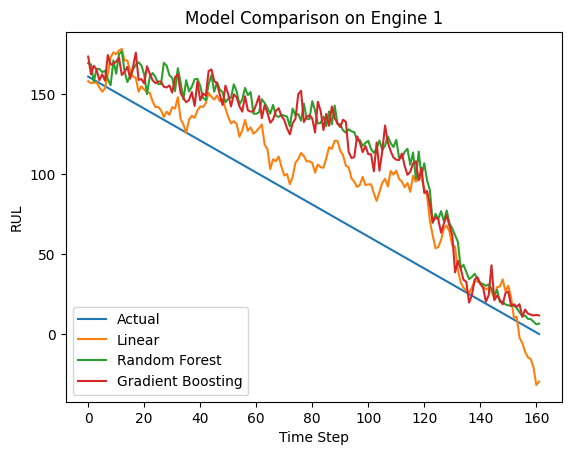

In [196]:
def compare_models_on_engine(engine_id, y_true, engine_ids, pred_lr, pred_rf, pred_gb):

    mask = engine_ids == engine_id

    plt.figure()

    plt.plot(y_true[mask])
    plt.plot(pred_lr[mask])
    plt.plot(pred_rf[mask])
    plt.plot(pred_gb[mask])

    plt.title(f"Model Comparison on Engine {engine_id}")
    plt.xlabel("Time Step")
    plt.ylabel("RUL")

    plt.legend(["Actual", "Linear", "Random Forest", "Gradient Boosting"])

    plt.savefig(f"model_compare_engine_{engine_id}.png", dpi=300, bbox_inches='tight')
    plt.show()

# Run (make sure you saved predictions from each model)
compare_models_on_engine(
    engine_id=1,
    y_true=y_test,
    engine_ids=test_engine_ids,
    pred_lr=pred_lr,
    pred_rf=pred_rf,
    pred_gb=pred
)

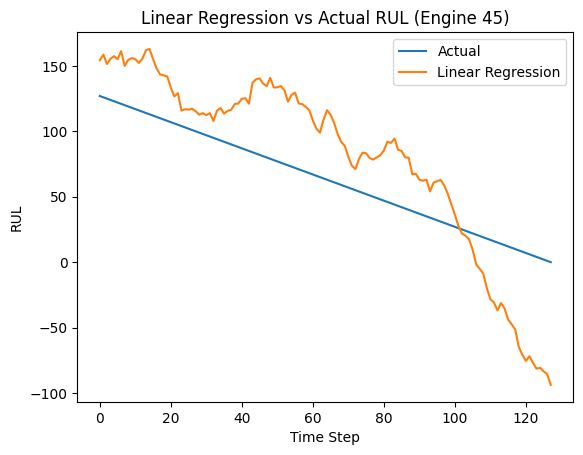

In [200]:
import numpy as np
import matplotlib.pyplot as plt

# pick a random engine (NOT engine 1)
unique_engines = np.unique(test_engine_ids)
engine_id = np.random.choice(unique_engines[unique_engines != 1])

mask = test_engine_ids == engine_id

plt.figure()

plt.plot(y_test[mask])
plt.plot(pred_lr[mask])

plt.title(f"Linear Regression vs Actual RUL (Engine {engine_id})")
plt.xlabel("Time Step")
plt.ylabel("RUL")

plt.legend(["Actual", "Linear Regression"])

plt.savefig(f"linear_vs_real_engine_{engine_id}.png", dpi=300, bbox_inches='tight')
plt.show()

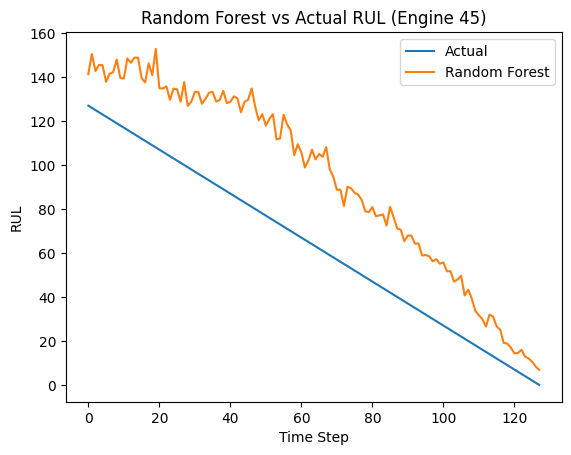

In [203]:
plt.figure()

plt.plot(y_test[mask])
plt.plot(pred_rf[mask])

plt.title(f"Random Forest vs Actual RUL (Engine {engine_id})")
plt.xlabel("Time Step")
plt.ylabel("RUL")

plt.legend(["Actual", "Random Forest"])

plt.savefig(f"rf_vs_real_engine_{engine_id}.png", dpi=300, bbox_inches='tight')
plt.show()

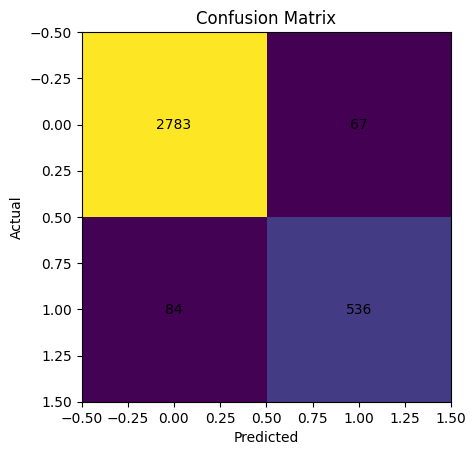

In [197]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_true_class, y_pred_class)

plt.figure()
plt.imshow(cm)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

Linear Regression CM:
 [[2844    6]
 [ 161  459]]

Random Forest CM:
 [[2827   23]
 [ 122  498]]

Gradient Boosting CM:
 [[2783   67]
 [  84  536]]


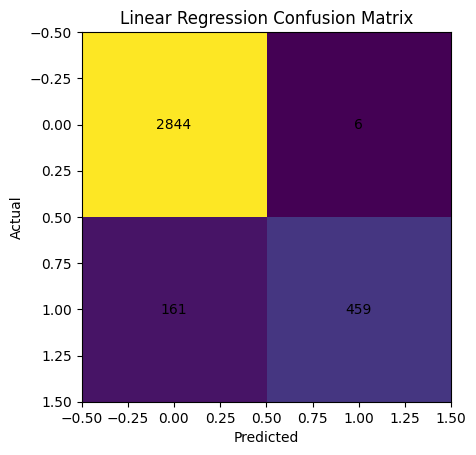

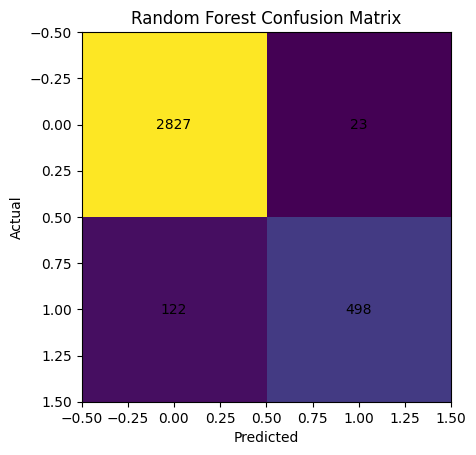

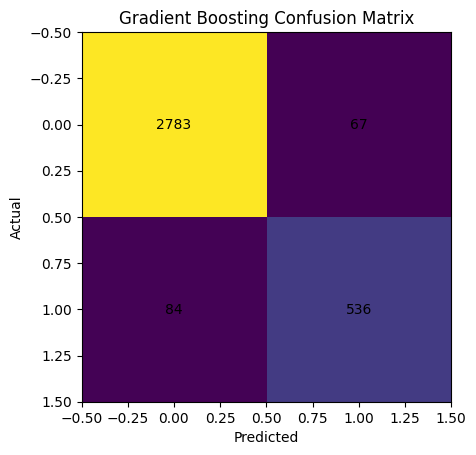

In [204]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# =========================
# CONFIG
# =========================
FAILURE_THRESHOLD = 30

# =========================
# CONVERT TO CLASS LABELS
# =========================
y_true_class = (y_test <= FAILURE_THRESHOLD).astype(int)

y_pred_lr = (pred_lr <= FAILURE_THRESHOLD).astype(int)
y_pred_rf = (pred_rf <= FAILURE_THRESHOLD).astype(int)
y_pred_gb = (pred <= FAILURE_THRESHOLD).astype(int)

# =========================
# CONFUSION MATRICES
# =========================
cm_lr = confusion_matrix(y_true_class, y_pred_lr)
cm_rf = confusion_matrix(y_true_class, y_pred_rf)
cm_gb = confusion_matrix(y_true_class, y_pred_gb)

print("Linear Regression CM:\n", cm_lr)
print("\nRandom Forest CM:\n", cm_rf)
print("\nGradient Boosting CM:\n", cm_gb)

# =========================
# PLOTTING FUNCTION
# =========================
def plot_cm(cm, title, save_name=None):
    plt.figure()
    plt.imshow(cm)

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center')

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    if save_name:
        plt.savefig(save_name, dpi=300, bbox_inches='tight')

    plt.show()

# =========================
# PLOTS
# =========================
plot_cm(cm_lr, "Linear Regression Confusion Matrix", "cm_linear.png")
plot_cm(cm_rf, "Random Forest Confusion Matrix", "cm_rf.png")
plot_cm(cm_gb, "Gradient Boosting Confusion Matrix", "cm_gb.png")